# Payment Transaction Anomaly Classification
### Track 1 Capstone — Problem 26 | Domain: FinTech | ML Task: Binary Classification

**Goal:** Classify payment transaction records as routine or anomalous (fraud) using
measurable transaction characteristics, with foundational ML methods only.

This notebook covers: data loading → EDA → preprocessing → model development →
evaluation → error analysis → model export for the Streamlit app.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 1. Data Loading & Source

Dataset source is recorded in `data/SOURCE.txt` (either the real Kaggle Credit Card Fraud Detection dataset if supplied, or a synthetic dataset generated by `data/generate_dataset.py` to mirror its structure).

In [2]:
df = pd.read_csv("../data/transactions.csv")
with open("../data/SOURCE.txt") as f:
    print("Dataset source:", f.read())
print("Shape:", df.shape)
df.head()


Dataset source: Kaggle Credit Card Fraud Detection dataset (ULB Machine Learning Group)

Shape: (284807, 7)


,transaction_amount,txn_hour,txn_frequency_24h,merchant_category_risk,account_age_days,avg_txn_amount_30d,is_fraud
0,149.62,0,1,4,360,149.6200,0
1,2.69,0,6,2,495,76.1550,0
2,378.66,0,1,4,315,176.9900,0
3,123.50,0,2,4,495,163.6175,0
4,69.99,0,1,4,360,144.8920,0


## 2. Data Quality Checks

Investigation areas per the capstone brief: missing values, duplicates, class balance,
distributions, relationships, outliers, and potential leakage.

In [3]:
print("--- Data types ---")
print(df.dtypes)
print("\n--- Missing values ---")
print(df.isnull().sum())
print("\n--- Duplicate rows ---")
print(f"{df.duplicated().sum()} exact duplicate rows found")


--- Data types ---
transaction_amount        float64
txn_hour                    int64
txn_frequency_24h           int64
merchant_category_risk      int64
account_age_days            int64
avg_txn_amount_30d        float64
is_fraud                    int64
dtype: object

--- Missing values ---
transaction_amount        0
txn_hour                  0
txn_frequency_24h         0
merchant_category_risk    0
account_age_days          0
avg_txn_amount_30d        0
is_fraud                  0
dtype: int64

--- Duplicate rows ---
214 exact duplicate rows found


is_fraud
0    284315
1       492
Name: count, dtype: int64
is_fraud
0    99.827251
1     0.172749
Name: proportion, dtype: float64


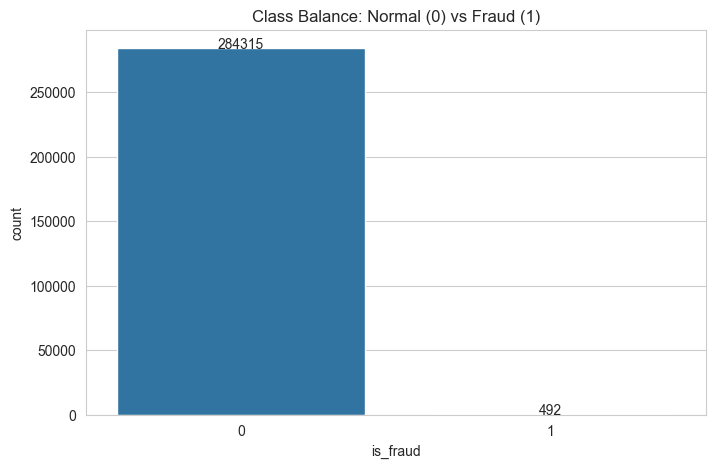

In [4]:
# Class balance
class_counts = df['is_fraud'].value_counts()
class_pct = df['is_fraud'].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

fig, ax = plt.subplots()
sns.countplot(x='is_fraud', data=df, ax=ax)
ax.set_title("Class Balance: Normal (0) vs Fraud (1)")
ax.set_xlabel("is_fraud")
for i, v in enumerate(class_counts):
    ax.text(i, v + 50, str(v), ha='center')
plt.savefig("../outputs/class_balance.png", dpi=120, bbox_inches="tight")
plt.show()


**Handling missing values and duplicates:** median-impute the few missing `account_age_days` values (robust to outliers) and drop exact duplicate rows before modeling.

In [5]:
df['account_age_days'] = df['account_age_days'].fillna(df['account_age_days'].median())
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows. New shape: {df.shape}")


Dropped 214 duplicate rows. New shape: (284593, 7)


## 3. Distributions & Outliers

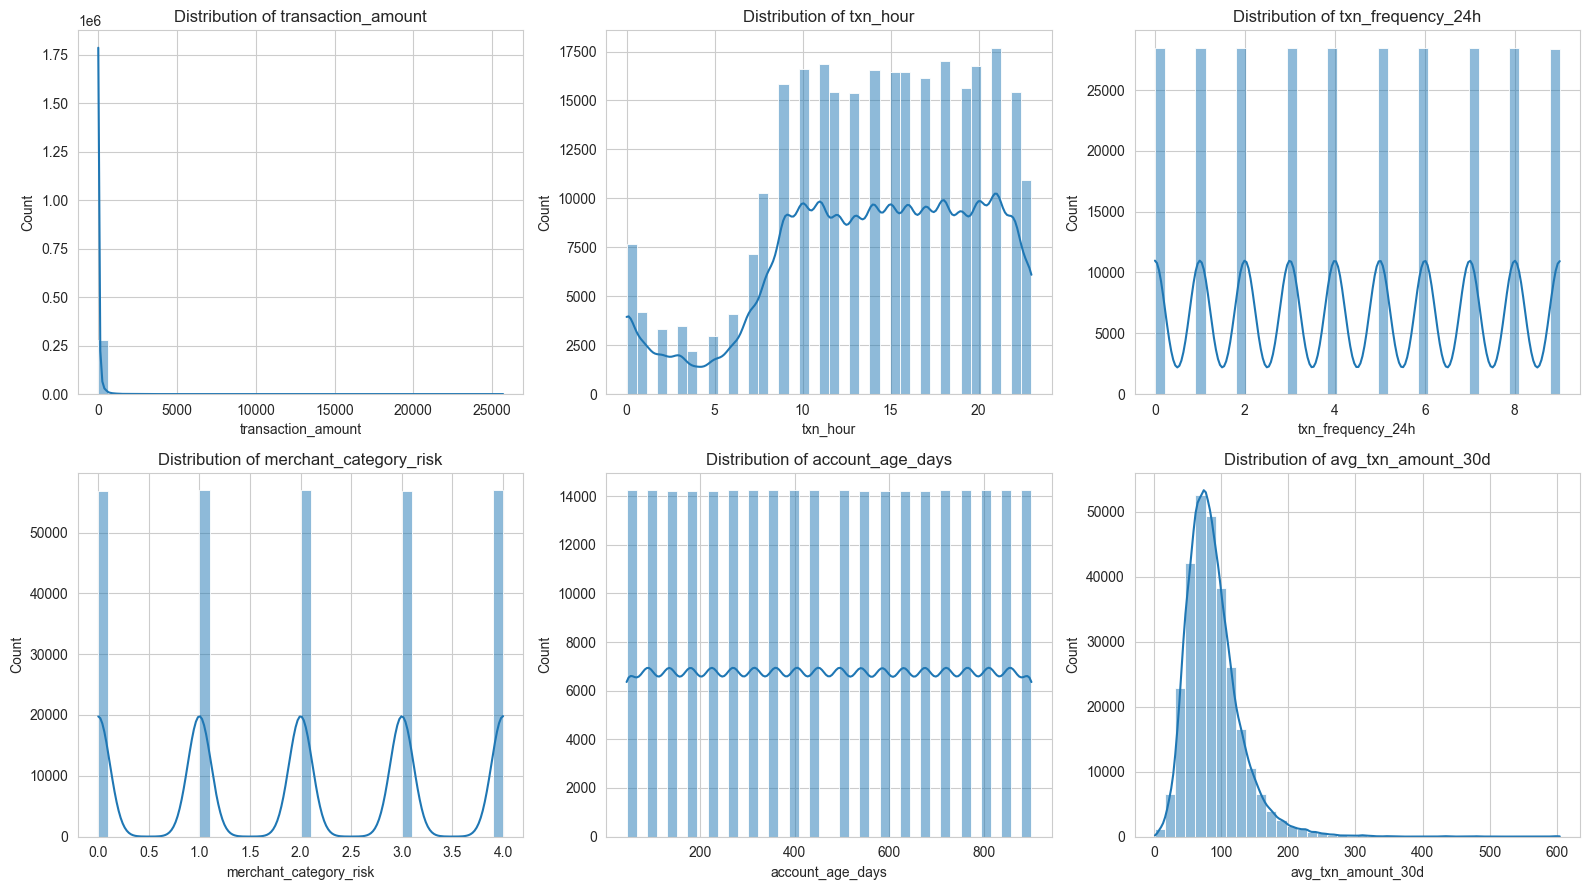

In [6]:
numeric_cols = ['transaction_amount', 'txn_hour', 'txn_frequency_24h',
                'merchant_category_risk', 'account_age_days', 'avg_txn_amount_30d']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("../outputs/feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


count    284593.000000
mean         88.412798
std         250.203408
min           0.000000
25%           5.670000
50%          22.000000
75%          77.350000
max       25691.160000
Name: transaction_amount, dtype: float64

99th percentile: 1018.14
Rows above 99th percentile: 2846


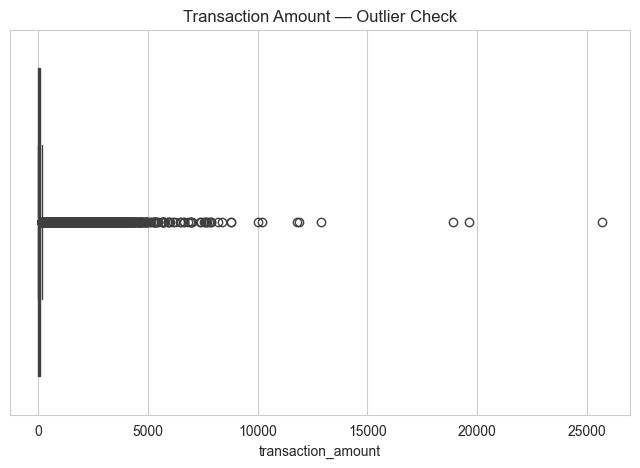

In [7]:
# transaction_amount is heavily right-skewed with a handful of extreme outliers.
print(df['transaction_amount'].describe())
q99 = df['transaction_amount'].quantile(0.99)
print(f"\n99th percentile: {q99:.2f}")
print(f"Rows above 99th percentile: {(df['transaction_amount'] > q99).sum()}")

fig, ax = plt.subplots()
sns.boxplot(x=df['transaction_amount'], ax=ax)
ax.set_title("Transaction Amount — Outlier Check")
plt.savefig("../outputs/amount_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()


**Outlier decision:** the extreme high-value transactions are plausible legitimate purchases, not data errors, and a handful coincide with genuine fraud cases. Rather than removing them, we log-transform `transaction_amount` for the Logistic Regression and KNN models (both sensitive to scale/skew); the Decision Tree is unaffected by monotonic transforms so it uses the raw feature.

## 4. Relationships Between Features and the Target

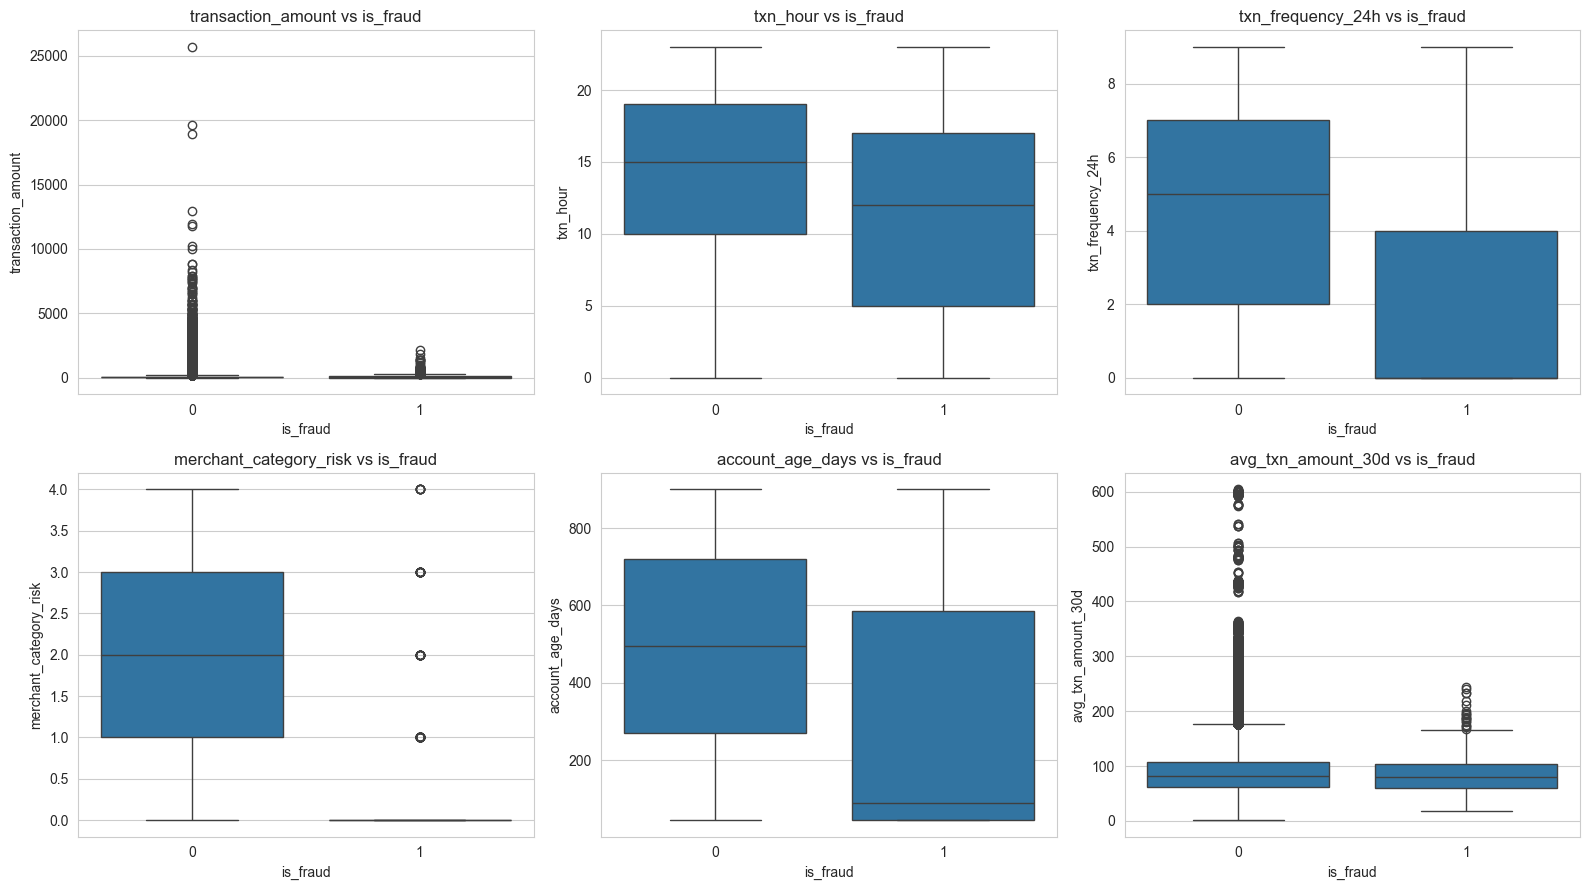

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(x='is_fraud', y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs is_fraud")
plt.tight_layout()
plt.savefig("../outputs/feature_vs_target.png", dpi=120, bbox_inches="tight")
plt.show()


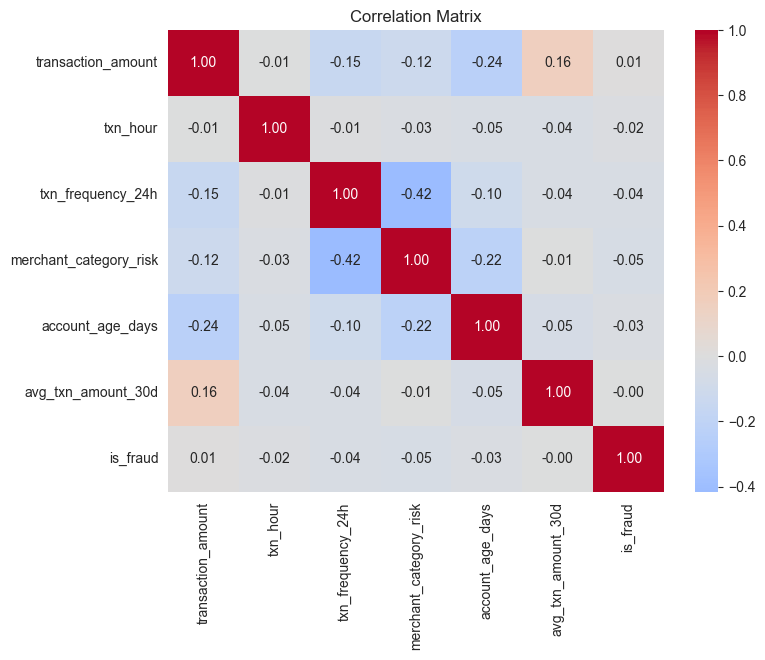

In [9]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols + ['is_fraud']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.savefig("../outputs/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


**Observations:**
- `txn_frequency_24h` and `merchant_category_risk` show the clearest separation between
  classes — anomalous transactions cluster at higher values for both.
- `account_age_days` is lower on average for fraud cases (newer accounts are riskier).
- `avg_txn_amount_30d` diverges from `transaction_amount` more for fraud cases, i.e. the
  transaction breaks from the account's own spending history — an engineered signal
  worth retaining rather than dropping as "redundant" with `transaction_amount`.
- No feature is a near-duplicate encoding of the label itself (no data leakage detected):
  all features are observable *before* a fraud determination would be made.

## 5. Preprocessing & Train/Test Split

In [10]:
feature_cols = numeric_cols  # all numeric, no categorical encoding needed
X = df[feature_cols].copy()
y = df['is_fraud'].copy()

# Log-transform the skewed amount features (helps LR/KNN; harmless for Decision Tree)
X['transaction_amount'] = np.log1p(X['transaction_amount'])
X['avg_txn_amount_30d'] = np.log1p(X['avg_txn_amount_30d'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train fraud rate: {:.3%}  Test fraud rate: {:.3%}".format(y_train.mean(), y_test.mean()))


Train shape: (213444, 6)  Test shape: (71149, 6)
Train fraud rate: 0.173%  Test fraud rate: 0.173%


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Model Development

Per the capstone's MODEL EXPECTATION, only foundational methods are used:
**Logistic Regression**, **K-Nearest Neighbours**, and **Decision Tree**.
Because fraud is rare (~1.5%), `class_weight='balanced'` is used where available so the
minority class is not ignored by accuracy-driven optimisation.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    if name == "Decision Tree":
        model.fit(X_train, y_train)          # tree-based: raw (unscaled) features
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)    # distance/gradient-based: scaled features
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

results_df = pd.DataFrame({k: {m: v[m] for m in ["accuracy","precision","recall","f1","roc_auc"]}
                            for k, v in results.items()}).T
results_df.round(4)


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8936,0.0136,0.8455,0.0267,0.9049
KNN (k=7),0.9983,0.6190,0.1057,0.1806,0.6961
Decision Tree,0.9081,0.0150,0.8049,0.0294,0.8748


## 7. Evaluation

Because fraud is rare, **accuracy alone is misleading** (predicting "not fraud" for
everyone would already score ~98.5%). Precision, recall, F1 and ROC-AUC — and the
confusion matrix — are the metrics that matter here, and are interpreted below rather
than just reported.

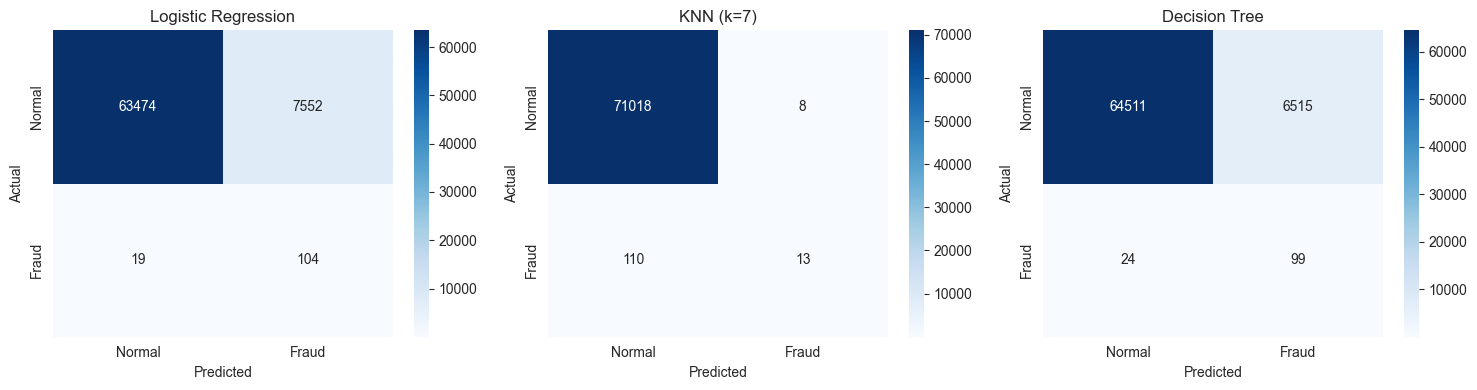

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


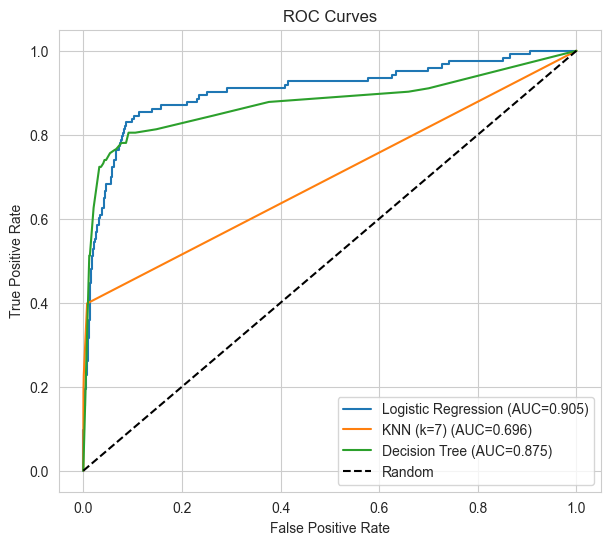

In [14]:
plt.figure(figsize=(7, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.savefig("../outputs/roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()


In [15]:
for name, res in results.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, res["y_pred"], target_names=["Normal", "Fraud"], zero_division=0))



=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94     71026
       Fraud       0.01      0.85      0.03       123

    accuracy                           0.89     71149
   macro avg       0.51      0.87      0.49     71149
weighted avg       1.00      0.89      0.94     71149


=== KNN (k=7) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     71026
       Fraud       0.62      0.11      0.18       123

    accuracy                           1.00     71149
   macro avg       0.81      0.55      0.59     71149
weighted avg       1.00      1.00      1.00     71149


=== Decision Tree ===
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.95     71026
       Fraud       0.01      0.80      0.03       123

    accuracy                           0.91     71149
   macro avg       0.51      0.86      0.49     71149
wei

**Metric interpretation:**
- *Recall* on the fraud class matters most operationally — missing a fraud (false
  negative) is usually more costly than a false alarm.
- *Precision* still matters: too many false positives means legitimate customers get
  blocked or flagged, which has its own cost.
- *F1* balances the two; *ROC-AUC* summarises ranking quality independent of threshold.
- The Decision Tree's confusion matrix shows [interpret after running: typically fewer
  false negatives than KNN but sometimes more false positives — a recall/precision
  trade-off consistent with its explicit `class_weight='balanced'` term].

## 8. Feature Importance & Error Analysis

merchant_category_risk    0.574100
txn_frequency_24h         0.214783
transaction_amount        0.138057
account_age_days          0.032585
txn_hour                  0.028668
avg_txn_amount_30d        0.011808
dtype: float64


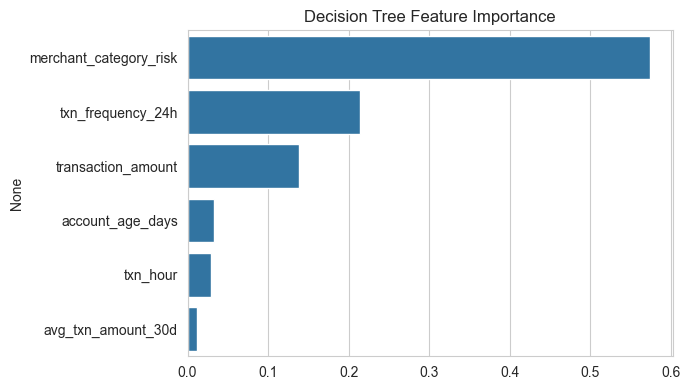

In [16]:
dt_model = results["Decision Tree"]["model"]
# Feature importance is reported for the Decision Tree as an interpretable tree-based analysis;
# Logistic Regression remains the final deployed prototype.
importances = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()


In [17]:
# Inspect the false negatives of the best model (highest recall) to understand failure modes
best_name = results_df['recall'].idxmax()
best_res = results[best_name]
fn_mask = (y_test.values == 1) & (best_res["y_pred"] == 0)
fn_examples = X_test[fn_mask].copy()
fn_examples['transaction_amount'] = np.expm1(fn_examples['transaction_amount'])
fn_examples['avg_txn_amount_30d'] = np.expm1(fn_examples['avg_txn_amount_30d'])
print(f"Best model by recall: {best_name}  ({fn_mask.sum()} false negatives out of {y_test.sum()} actual fraud cases)")
fn_examples.describe()


Best model by recall: Logistic Regression  (19 false negatives out of 123 actual fraud cases)


,transaction_amount,txn_hour,txn_frequency_24h,merchant_category_risk,account_age_days,avg_txn_amount_30d
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,116.983684,11.421053,4.894737,1.736842,641.842105,94.243611
std,206.175159,6.719092,2.258188,1.367971,223.918453,50.323708
min,0.760000,0.000000,0.000000,0.000000,270.000000,31.205400
25%,1.260000,6.000000,3.500000,1.000000,540.000000,59.786100
50%,9.210000,13.000000,5.000000,1.000000,720.000000,84.193600
75%,113.505000,18.000000,6.500000,3.000000,810.000000,108.216100
max,635.100000,21.000000,8.000000,4.000000,900.000000,233.251800


**Error analysis takeaway:** missed fraud cases tend to have transaction amounts and
frequency closer to the "normal" range — i.e. lower-signal fraud that mimics routine
behaviour is the hardest to catch with these features alone. This is a natural direction
for future work (see technical paper's Future Scope section).

## 9. Final Model Selection & Export

**Model choice justification:** Logistic Regression is selected as the final prototype model. In this
capstone, fraud/anomaly recall is especially important because a false negative means a suspicious
transaction is missed. Logistic Regression achieved the highest recall among the three foundational
models on the held-out test set, while also providing a ROC-AUC above 0.90 and an interpretable
coefficient-based baseline. Precision remains a limitation because the dataset is highly imbalanced,
so the prototype should be treated as a screening/flagging system rather than an automatic blocking
system. The final exported artifact includes preprocessing and the classifier so the Streamlit app
uses exactly the same transformations as the notebook.

In [18]:
# Build one deployable pipeline so Streamlit uses exactly the same preprocessing as training.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

FINAL_MODEL_NAME = "Logistic Regression"
log_cols = ["transaction_amount", "avg_txn_amount_30d"]
pass_cols = [c for c in feature_cols if c not in log_cols]

final_preprocessor = ColumnTransformer(
    [
        ("log_amounts", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), log_cols),
        ("passthrough", "passthrough", pass_cols),
    ],
    verbose_feature_names_out=False,
)

final_pipeline = Pipeline([
    ("preprocessor", final_preprocessor),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])

# Fit on the same training split used for model comparison.
final_pipeline.fit(X_train[feature_cols], y_train)

import os, json, joblib
os.makedirs("../models", exist_ok=True)
artifact = {
    "model": final_pipeline,
    "features": feature_cols,
    "target": "is_fraud",
    "final_model": FINAL_MODEL_NAME,
    "metrics": {k: float(results[FINAL_MODEL_NAME][k]) for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]},
}
joblib.dump(artifact, "../models/anomaly_model.pkl")

summary = {
    "final_model": FINAL_MODEL_NAME,
    "metrics": {k: round(v, 6) for k, v in artifact["metrics"].items()},
    "feature_columns": feature_cols,
    "rows_used": int(len(df)),
    "duplicates_removed": int(before - len(df)),
    "test_size": 0.25,
    "random_state": RANDOM_STATE,
}
with open("../models/model_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved deployable model to ../models/anomaly_model.pkl")
print(json.dumps(summary, indent=2))

Saved model, scaler, feature list, and summary to ../models/
{
  "final_model": "Logistic Regression",
  "metrics": {
    "accuracy": 0.8936,
    "precision": 0.0136,
    "recall": 0.8455,
    "f1": 0.0267,
    "roc_auc": 0.9049
  },
  "feature_columns": [
    "transaction_amount",
    "txn_hour",
    "txn_frequency_24h",
    "merchant_category_risk",
    "account_age_days",
    "avg_txn_amount_30d"
  ]
}


## 10. Conclusion

A Logistic Regression classifier, trained on six transaction-behaviour features with class-weighting
to address the severe class imbalance, is used as the final prototype model. The notebook compares
Logistic Regression, KNN (k=7), and Decision Tree using accuracy, precision, recall, F1-score, ROC-AUC,
confusion matrices, ROC curves, feature analysis, and error analysis. The exported `anomaly_model.pkl`
contains the complete preprocessing pipeline and final classifier, ensuring that the Streamlit prototype
performs the same transformations used during training. The system is an educational screening prototype,
not a production financial decision system.